$$I= \int_0^\infty x^3 \exp\left(-\frac{x^2}{2\sigma^2}\right) \,dx = 2\sigma^4 .$$

Monte carlo integration: int f p dx = 1/N Sum f(x_i) with x_i drawn from p

In [31]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [70]:
N = 10000
mu = 0
sigma = 1
p = scipy.stats.norm(loc=mu, scale=sigma)
result = 2*sigma**4

In [71]:
x = np.abs(p.rvs(N))
integ = np.mean(x**3)*np.sqrt(np.pi/2)*sigma
print(integ)
print(result)

1.9729476030770536
2


In [72]:
def integral(m, s, n):
    p = scipy.stats.norm(loc=m, scale=s)
    x = np.abs(p.rvs(n))
    return np.mean(x**3)*np.sqrt(np.pi/2)*s

In [73]:
# convergence with the number of samples, error trend
y = [integral(mu, sigma, n) for n in range(1,N)]
n = np.arange(1,N)


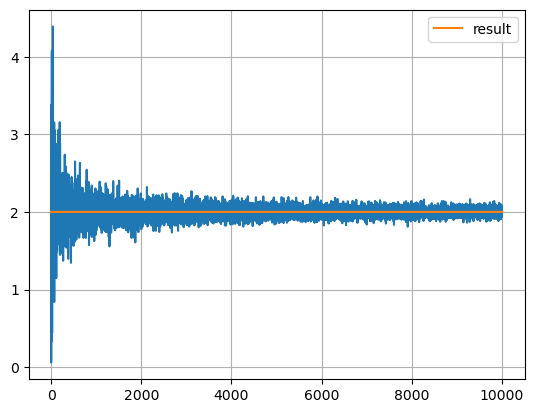

In [74]:
plt.plot(n,y)
plt.plot(n, np.ones(N-1)*result, label = 'result')
plt.grid(True)
plt.legend()

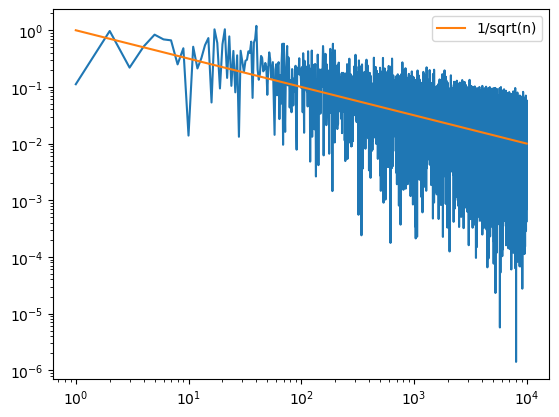

In [75]:
plt.loglog(n, np.abs(y-np.ones(N-1)*result)/(np.ones(N-1)*result))
plt.loglog(n, 1/np.sqrt(n), label = '1/sqrt(n)')
plt.legend()

In [ ]:
# distribution for given N and fit
rep = 1000
N = 1000
res = np.zeros(rep)

for i in range(rep):
    res[i] = integral(mu, sigma, N)

Text(0.5, 1.0, 'Parametric fit')

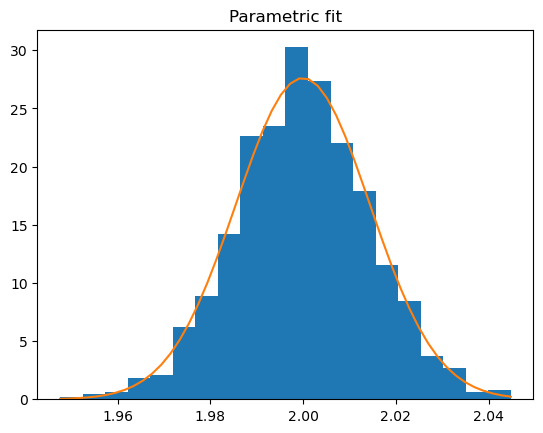

In [91]:
_ , bin_lim, _ = plt.hist(res, bins=20, density = True)
g = scipy.stats.norm(loc = np.mean(res), scale = np.std(res, ddof = 1))
points = np.linspace(bin_lim[0], bin_lim[-1])
plt.plot(points, g.pdf(points))
plt.title('Parametric fit')

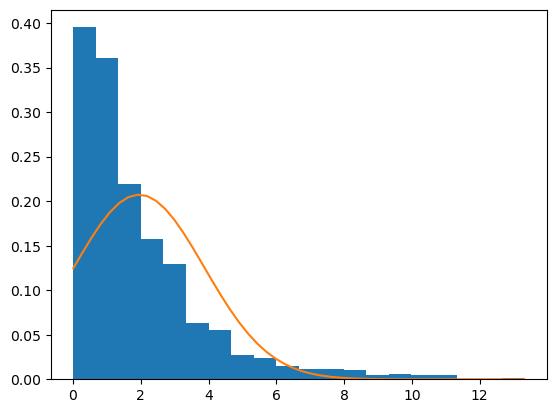

In [87]:
# small N
# distribution for given N and fit
rep = 1000
N = 5
res = np.zeros(rep)

for i in range(rep):
    res[i] = integral(mu, sigma, N)
_ , bin_lim, _ = plt.hist(res, bins=20, density = True)
g = scipy.stats.norm(loc = np.mean(res), scale = np.std(res, ddof = 1))
points = np.linspace(bin_lim[0], bin_lim[-1])
plt.plot(points, g.pdf(points))

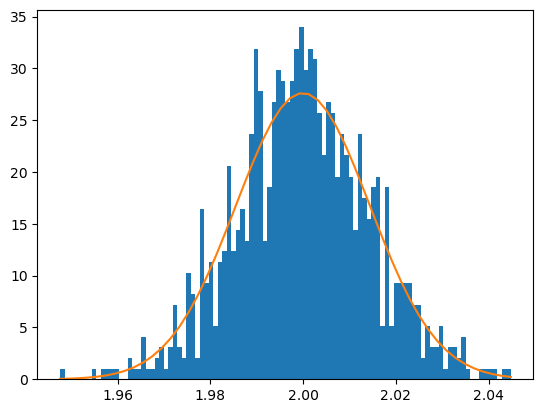

In [90]:
# increasing N
# distribution for given N and fit
rep = 1000
N = 100000
res = np.zeros(rep)

for i in range(rep):
    res[i] = integral(mu, sigma, N)
_ , bin_lim, _ = plt.hist(res, bins=100, density = True)
g = scipy.stats.norm(loc = np.mean(res), scale = np.std(res, ddof = 1))
points = np.linspace(bin_lim[0], bin_lim[-1])
plt.plot(points, g.pdf(points))